In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

IMG_SIZE = (380, 380)
TEST_SIZE = 0.20

USE_DULL_RAZOR = False
USE_MASK_SEGMENTATION = False
USE_MASK_CROP = True
CROP_MARGIN = 20

FEATURE_EXTRACTOR_PATH = "efficientnetb4_crop_380_feature_extractor.keras"
CLASSIFIER_PATH = "best_efficientnetb4_crop_smote_380.keras"

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print("IMG_SIZE:", IMG_SIZE)
print("USE_DULL_RAZOR:", USE_DULL_RAZOR)
print("USE_MASK_SEGMENTATION:", USE_MASK_SEGMENTATION)
print("USE_MASK_CROP:", USE_MASK_CROP)
print("CROP_MARGIN:", CROP_MARGIN)
print("FEATURE_EXTRACTOR_PATH:", FEATURE_EXTRACTOR_PATH)
print("CLASSIFIER_PATH:", CLASSIFIER_PATH)

IMG_SIZE: (380, 380)
USE_DULL_RAZOR: False
USE_MASK_SEGMENTATION: False
USE_MASK_CROP: True
CROP_MARGIN: 20
FEATURE_EXTRACTOR_PATH: efficientnetb4_crop_380_feature_extractor.keras
CLASSIFIER_PATH: best_efficientnetb4_crop_smote_380.keras


In [3]:
def find_image_path(image_id, images_dir):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = images_dir / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_mask.jpg",
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_image_path(image_id, IMAGES_DIR)
    mask_path = find_mask_path(image_id, MASKS_DIR)

    if image_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

print("Total de imagens:", len(df))
print("Treino:", len(train_df))
print("Teste:", len(test_df))

print("\nDistribuição do teste:")
print(test_df["class_name"].value_counts().reindex(classes))

Total de imagens: 10015
Treino: 8012
Teste: 2003

Distribuição do teste:
class_name
MEL       223
NV       1341
BCC       103
AKIEC      65
BKL       220
DF         23
VASC       28
Name: count, dtype: int64


In [4]:
def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")

    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    return image_rgb


def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)

    _, mask = cv2.threshold(blackhat_blur, threshold_value, 255, cv2.THRESH_BINARY)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    clean_bgr = cv2.inpaint(image_bgr, mask, inpaint_radius, cv2.INPAINT_TELEA)
    clean_rgb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)

    return clean_rgb


def read_binary_mask(mask_path, target_shape):
    if mask_path is None or pd.isna(mask_path):
        return None

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    height, width = target_shape[:2]
    mask = cv2.resize(mask, (width, height))
    binary_mask = (mask > 127).astype(np.uint8)

    return binary_mask


def apply_mask_segmentation(image_rgb, mask_path):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    segmented = image_rgb * np.expand_dims(binary_mask, axis=-1)

    if np.mean(segmented) < 5:
        return image_rgb

    return segmented


def crop_lesion_with_margin(image_rgb, mask_path, margin=20):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return image_rgb

    height, width = image_rgb.shape[:2]

    x_min = max(xs.min() - margin, 0)
    x_max = min(xs.max() + margin, width - 1)
    y_min = max(ys.min() - margin, 0)
    y_max = min(ys.max() + margin, height - 1)

    cropped = image_rgb[y_min:y_max + 1, x_min:x_max + 1]

    if cropped.size == 0:
        return image_rgb

    return cropped


def preprocess_image_path(path, mask_path=None):
    image_rgb = read_rgb_image(path)

    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)

    if USE_MASK_CROP:
        image_rgb = crop_lesion_with_margin(image_rgb, mask_path, margin=CROP_MARGIN)
    elif USE_MASK_SEGMENTATION:
        image_rgb = apply_mask_segmentation(image_rgb, mask_path)

    image_rgb = cv2.resize(image_rgb, IMG_SIZE)

    return image_rgb.astype("float32")

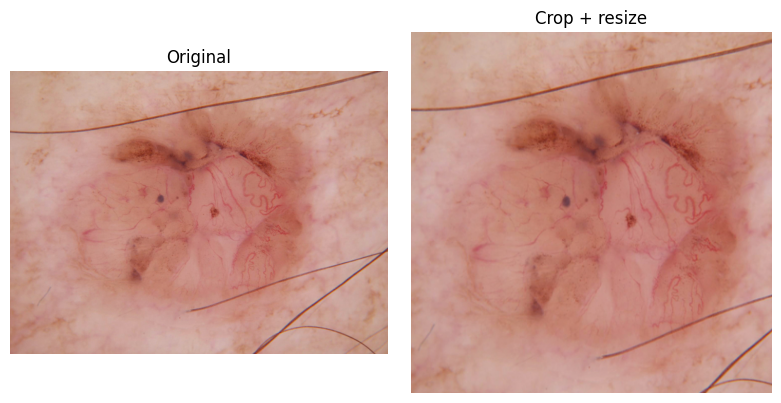

In [5]:
sample_row = test_df.sample(1, random_state=SEED).iloc[0]

original = read_rgb_image(sample_row["image_path"])
processed = preprocess_image_path(sample_row["image_path"], sample_row["mask_path"])
processed = np.clip(processed, 0, 255).astype("uint8")

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Crop + resize")
plt.axis("off")

plt.tight_layout()
plt.savefig("tta_preprocessamento_exemplo.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
feature_extractor = keras.models.load_model(FEATURE_EXTRACTOR_PATH)
best_classifier = keras.models.load_model(CLASSIFIER_PATH)

print("Extratora carregada:", FEATURE_EXTRACTOR_PATH)
print("Classificador carregado:", CLASSIFIER_PATH)

Extratora carregada: efficientnetb4_crop_380_feature_extractor.keras
Classificador carregado: best_efficientnetb4_crop_smote_380.keras


In [7]:
def generate_tta_images(image):
    image = image.astype("float32")

    tta_images = [
        image,
        np.fliplr(image),
        np.flipud(image),
        np.flipud(np.fliplr(image)),
    ]

    return np.array(tta_images, dtype="float32")


def predict_with_tta(image_path, mask_path, feature_extractor, classifier):
    image = preprocess_image_path(image_path, mask_path)
    tta_images = generate_tta_images(image)

    features = feature_extractor.predict(tta_images, verbose=0)
    preds = classifier.predict(features, verbose=0)

    mean_pred = np.mean(preds, axis=0)

    return mean_pred

In [8]:
y_true_tta = []
y_pred_tta = []

for _, row in test_df.reset_index(drop=True).iterrows():
    pred = predict_with_tta(
        row["image_path"],
        row["mask_path"],
        feature_extractor,
        best_classifier
    )

    pred_class = np.argmax(pred)

    y_true_tta.append(int(row["label"]))
    y_pred_tta.append(pred_class)

y_true_tta = np.array(y_true_tta)
y_pred_tta = np.array(y_pred_tta)

print("Avaliação com TTA concluída.")

Avaliação com TTA concluída.


In [9]:
print("Relatório de Classificação com TTA:")
print(classification_report(
    y_true_tta,
    y_pred_tta,
    target_names=classes,
    digits=4,
    zero_division=0
))

acc_tta = accuracy_score(y_true_tta, y_pred_tta)

macro_precision_tta = precision_score(y_true_tta, y_pred_tta, average="macro", zero_division=0)
macro_recall_tta = recall_score(y_true_tta, y_pred_tta, average="macro", zero_division=0)
macro_f1_tta = f1_score(y_true_tta, y_pred_tta, average="macro", zero_division=0)

weighted_precision_tta = precision_score(y_true_tta, y_pred_tta, average="weighted", zero_division=0)
weighted_recall_tta = recall_score(y_true_tta, y_pred_tta, average="weighted", zero_division=0)
weighted_f1_tta = f1_score(y_true_tta, y_pred_tta, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO MODELO COM TTA")
print(f"Accuracy: {acc_tta:.4f}")

print("\nMacro Average:")
print(f"  Precision: {macro_precision_tta:.4f}")
print(f"  Recall: {macro_recall_tta:.4f}")
print(f"  F1-Score: {macro_f1_tta:.4f}")

print("\nWeighted Average:")
print(f"  Precision: {weighted_precision_tta:.4f}")
print(f"  Recall: {weighted_recall_tta:.4f}")
print(f"  F1-Score: {weighted_f1_tta:.4f}")

Relatório de Classificação com TTA:
              precision    recall  f1-score   support

         MEL     0.7333    0.5919    0.6551       223
          NV     0.9040    0.9553    0.9289      1341
         BCC     0.7429    0.7573    0.7500       103
       AKIEC     0.5890    0.6615    0.6232        65
         BKL     0.7366    0.6227    0.6749       220
          DF     0.7368    0.6087    0.6667        23
        VASC     0.8696    0.7143    0.7843        28

    accuracy                         0.8512      2003
   macro avg     0.7589    0.7017    0.7262      2003
weighted avg     0.8457    0.8512    0.8464      2003


MÉTRICAS GERAIS DO MODELO COM TTA
Accuracy: 0.8512

Macro Average:
  Precision: 0.7589
  Recall: 0.7017
  F1-Score: 0.7262

Weighted Average:
  Precision: 0.8457
  Recall: 0.8512
  F1-Score: 0.8464


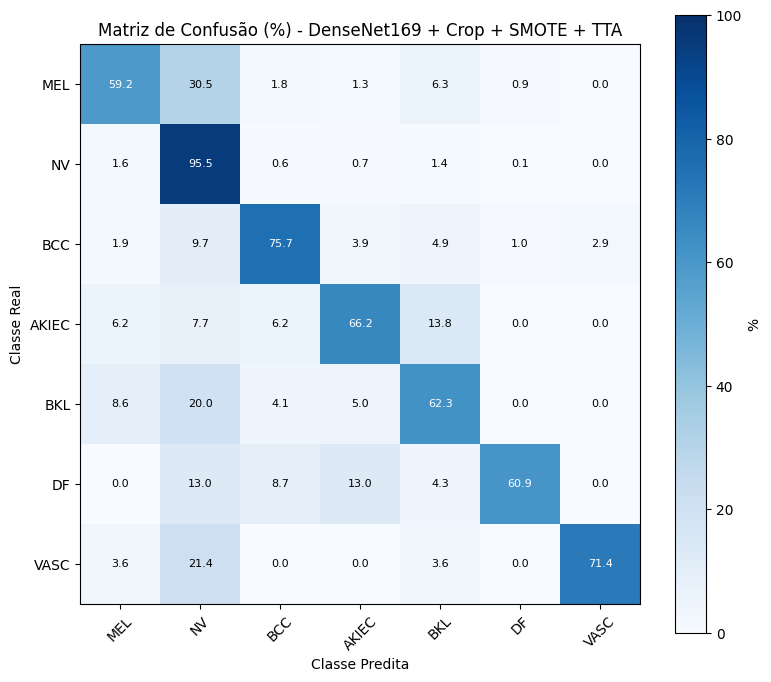

In [10]:
cm_tta = confusion_matrix(y_true_tta, y_pred_tta, labels=list(range(len(classes))))
cm_percent_tta = cm_tta.astype("float") / cm_tta.sum(axis=1, keepdims=True) * 100
cm_percent_tta = np.nan_to_num(cm_percent_tta)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent_tta, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
plt.title("Matriz de Confusão (%) - DenseNet169 + Crop + SMOTE + TTA")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent_tta.shape[0]):
    for j in range(cm_percent_tta.shape[1]):
        color = "white" if cm_percent_tta[i, j] > 50 else "black"
        plt.text(
            j,
            i,
            f"{cm_percent_tta[i, j]:.1f}",
            ha="center",
            va="center",
            color=color,
            fontsize=8
        )

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_percent_densenet169_crop_smote_tta.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
print("Resultado anterior sem TTA:")
print("Accuracy: 0.8537")
print("F1 macro: 0.7514")
print("F1 ponderado: 0.8499")

print("\nResultado com TTA:")
print(f"Accuracy: {acc_tta:.4f}")
print(f"F1 macro: {macro_f1_tta:.4f}")
print(f"F1 ponderado: {weighted_f1_tta:.4f}")

Resultado anterior sem TTA:
Accuracy: 0.8537
F1 macro: 0.7514
F1 ponderado: 0.8499

Resultado com TTA:
Accuracy: 0.8512
F1 macro: 0.7262
F1 ponderado: 0.8464
